# Blue vs. Red

## Problem Statement

There are two buttons and you must choose one: a red (R) and a blue (B).

Given a global population of N, if n is the number of people who vote red:
- n/N <= 0.5:   nobody dies (N people live)
- n/N > 0.5:    all the people who voted blue die (N-n people die)

Let the percentage of the population that you think will vote red be \gamma
Suppose that you have two priorities with weights phi1 and phi2: 
1. To live.
2. To not kill others.

What is the optimal strategy?


either:
1. I vote R and R wins (N-n people die)
U = phi1 * 1 + phi2 * n (n<N/2)
2. I vote B and R wins (I die AND N-n people die)
U = phi2 * n
3. I vote R and B wins (nobody dies)
U = phi1 * 1 + phi2 * N
4. I vote B and B wins (nobody dies)
U = phi1 * 1 + phi2 * N

The utility of voting R, then, is:
U(R) = R_0 * (phi1 * 1 + phi2 * n) + (1-R_0) * (phi1 * 1 + phi2 * N)
The utility of voting B:
U(B) = R_0 * (phi2 * n) + (1-R_0) * (phi1 * 1 + phi2 * N)

The change in utility is:
dU = U(R) - U(B)
That way, if dU<0 means that B is better, dU=0 means that there's no difference, dU>0 means that R is better
dU = R_0 * (phi1 * 1 + phi2 * n) - R_0 * (phi2 * n)
dU = 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
from typing import Optional


In [2]:
def compute_expected_utilities(N: int, phi1: float, phi2: float, gamma: float, threshold: Optional[float] = 0.5):
    """
    Core vectorized computation of expected utilities for Red and Blue.

    phi1, phi2, gamma may each be a scalar or a numpy array of any shape.
    The k-summation (over the N possible vote counts) is handled internally
    via broadcasting on the last axis, so the returned arrays have the same
    shape as the broadcast of phi1 / gamma.

    Returns
    -------
    E_red, E_blue : ndarray (or float when inputs are scalar)
    """
    phi1_b  = np.asarray(phi1,  dtype=float)[..., np.newaxis]
    phi2_b  = np.asarray(phi2,  dtype=float)[..., np.newaxis]
    gamma_b = np.asarray(gamma, dtype=float)[..., np.newaxis]

    k = np.arange(N)                                  # shape (N,)
    probabilities = binom.pmf(k, N - 1, gamma_b)      # shape (..., N)

    majority = N * threshold

    u_red = np.where(
        (k + 1) > majority,
        phi1_b + phi2_b * k,
        phi1_b + phi2_b * (N - 1),
    )

    u_blue = np.where(
        k > majority,
        phi2_b * k,
        phi1_b + phi2_b * (N - 1),
    )

    E_red  = np.sum(probabilities * u_red,  axis=-1)
    E_blue = np.sum(probabilities * u_blue, axis=-1)
    return E_red, E_blue


In [3]:
def evaluate_voting_strategy(N: int, phi1: float, phi2: float, gamma: float, threshold: Optional[float] = 0.5):
    """
    Evaluates the expected utility of voting Red vs. Blue for a single parameter point.

    Parameters
    ----------
    N     : int   – total population size (>= 2)
    phi1  : float – utility weight of your own life
    phi2  : float – utility weight per other person's life saved
    gamma : float – probability in [0, 1] that any other person votes Red

    Returns
    -------
    dict with keys: Expected_Utility_Red, Expected_Utility_Blue, Delta_E, Optimal_Choice
    """
    if N < 2:
        raise ValueError("Population N must be at least 2.")
    if not (0.0 <= gamma <= 1.0):
        raise ValueError("Gamma must be a valid probability between 0.0 and 1.0.")

    E_red, E_blue = compute_expected_utilities(N, phi1, phi2, gamma, threshold)
    delta_e = float(E_red) - float(E_blue)

    if delta_e > 1e-9:
        decision = "Vote RED"
    elif delta_e < -1e-9:
        decision = "Vote BLUE"
    else:
        decision = "Indifferent"

    return {
        "Expected_Utility_Red":  float(E_red),
        "Expected_Utility_Blue": float(E_blue),
        "Delta_E":               delta_e,
        "Optimal_Choice":        decision,
    }


In [4]:
def compute_sweep(N: Optional[int] = 100, resolution: Optional[int] = 300, ratio_min: Optional[float] = 1e-3, ratio_max: Optional[float] = 10.0, ratio_scale: Optional[str] = "linear", threshold: Optional[float] = 0.5):
    """
    Computes the delta_E grid over (gamma, phi1/phi2 ratio) parameter space.

    phi2 is fixed at 1.0, so the ratio axis equals phi1 directly.

    Parameters
    ----------
    N            : int    – total population size
    resolution   : int    – number of sample points along each axis
    ratio_min    : float  – lower bound for the ratio axis; must be > 0 for log scale
    ratio_max    : float  – upper bound for the ratio axis
    ratio_scale  : str    – "linear" or "log"

    Returns
    -------
    dict with keys: gamma_grid, ratio_grid, delta_e, N, ratio_scale, ratio_min, ratio_max
    """
    phi2 = 1.0
    gamma_vals = np.linspace(0.0, 1.0, resolution)

    if ratio_scale == "log":
        if ratio_min <= 0:
            raise ValueError("ratio_min must be > 0 when ratio_scale='log'.")
        ratio_vals = np.logspace(np.log10(ratio_min), np.log10(ratio_max), resolution)
    elif ratio_scale == "linear":
        ratio_vals = np.linspace(ratio_min, ratio_max, resolution)
    else:
        raise ValueError("ratio_scale must be either 'linear' or 'log'.")

    gamma_grid, ratio_grid = np.meshgrid(gamma_vals, ratio_vals)

    E_red, E_blue = compute_expected_utilities(N, ratio_grid, phi2, gamma_grid, threshold)
    delta_e = E_red - E_blue

    return {
        "gamma_grid": gamma_grid,
        "ratio_grid": ratio_grid,
        "delta_e": delta_e,
        "N": N,
        "ratio_scale": ratio_scale,
        "ratio_min": ratio_min,
        "ratio_max": ratio_max,
    }


In [5]:
def plot_sweep(sweep_result: dict, vmax_clip: Optional[float] = 5.0, yscale: Optional[str] = None):
    """
    Renders the parameter sweep heat-map from the dict returned by compute_sweep().

    Parameters
    ----------
    sweep_result : dict  – output of compute_sweep()
    vmax_clip    : float – color-scale cap (highlights the decision boundary)
    yscale       : str | None – "linear", "log", or None to follow sweep_result metadata
    """
    gamma_grid = sweep_result["gamma_grid"]
    ratio_grid = sweep_result["ratio_grid"]
    delta_e    = sweep_result["delta_e"]
    N          = sweep_result["N"]

    resolved_yscale = yscale or sweep_result.get("ratio_scale", "linear")

    fig, ax = plt.subplots(figsize=(10, 4))

    cf = ax.contourf(
        gamma_grid, ratio_grid, delta_e,
        levels=100, cmap="coolwarm",
        vmin=-vmax_clip, vmax=vmax_clip, extend="both",
    )
    fig.colorbar(cf, ax=ax, label="Expected Utility Difference (ΔE)")

    ax.contour(
        gamma_grid, ratio_grid, delta_e,
        levels=[0], colors="black", linewidths=2.5,
    )

    if resolved_yscale == "log":
        ax.set_yscale("log")
        ax.set_ylim(sweep_result.get("ratio_min", ratio_grid.min()), sweep_result.get("ratio_max", ratio_grid.max()))

    ax.set_title(f"Optimal Voting Strategy (N={N})", fontsize=12)
    ax.set_xlabel("Gamma: Expected % voting Red (γ)", fontsize=12)
    ax.set_ylabel("(φ1 / φ2)", fontsize=12)

    plt.tight_layout()
    plt.savefig("voting_parameter_sweep.png", dpi=150)
    plt.show()


# ── Run ────────────────────────────────────────────────────────────────────────
#plot_sweep(compute_sweep(N=10000, resolution=100, ratio_min=0, ratio_max=10, ratio_scale="linear"))


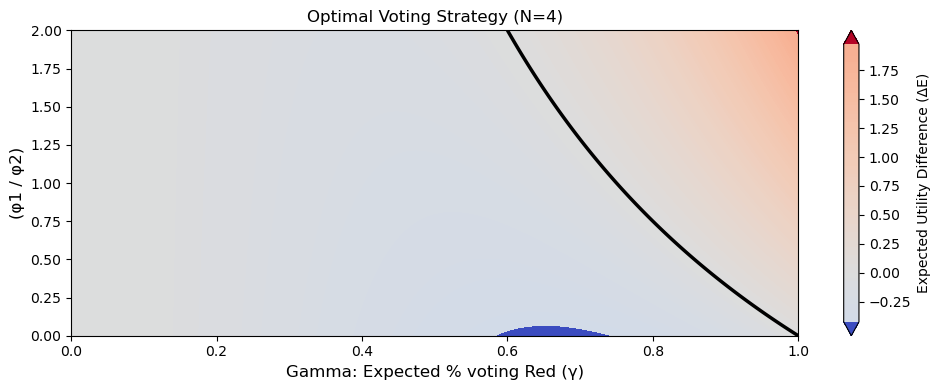

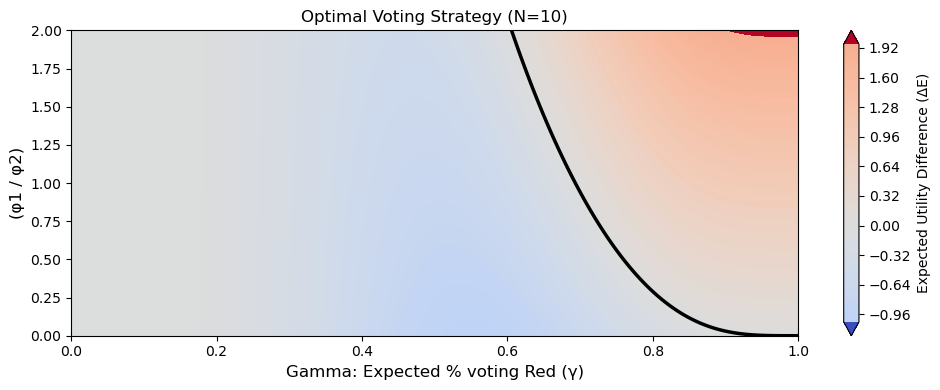

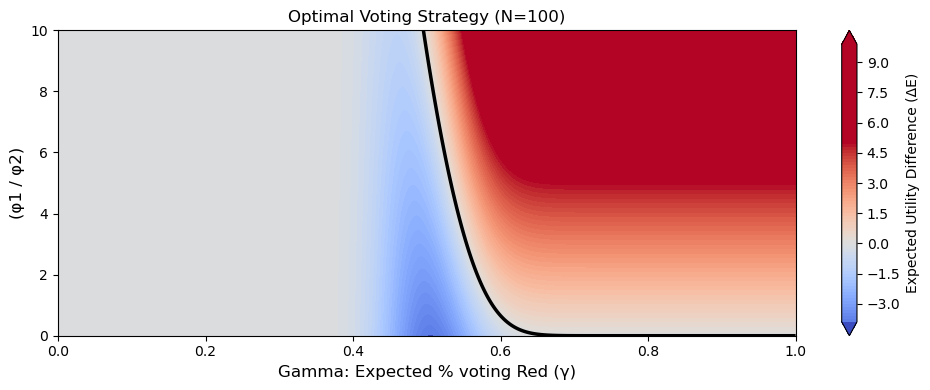

In [6]:
# ── Run ────────────────────────────────────────────────────────────────────────
plot_sweep(compute_sweep(N=4, resolution=1000, ratio_min=0, ratio_max=2, ratio_scale="linear"))
plot_sweep(compute_sweep(N=10, resolution=1000, ratio_min=0, ratio_max=2, ratio_scale="linear"))
plot_sweep(compute_sweep(N=100, resolution=1000, ratio_min=0, ratio_max=10, ratio_scale="linear"))
#plot_sweep(compute_sweep(N=1000, resolution=1000, ratio_min=0, ratio_max=2, ratio_scale="linear"))

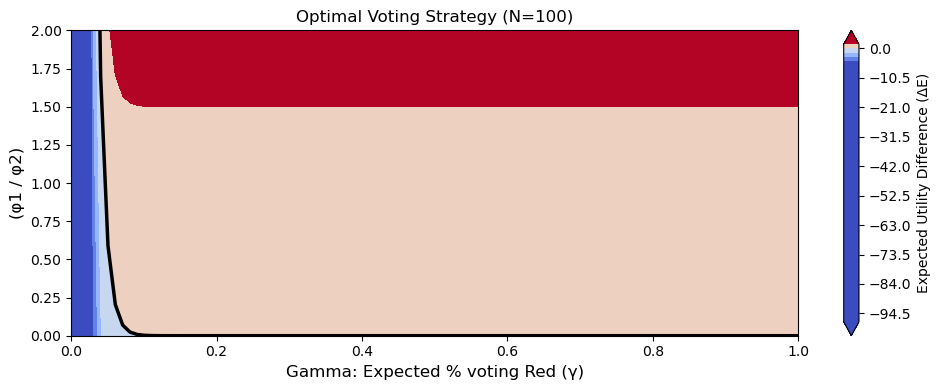

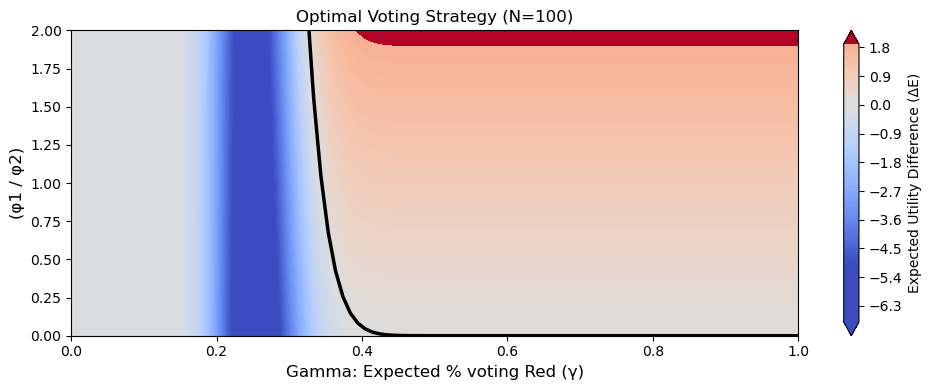

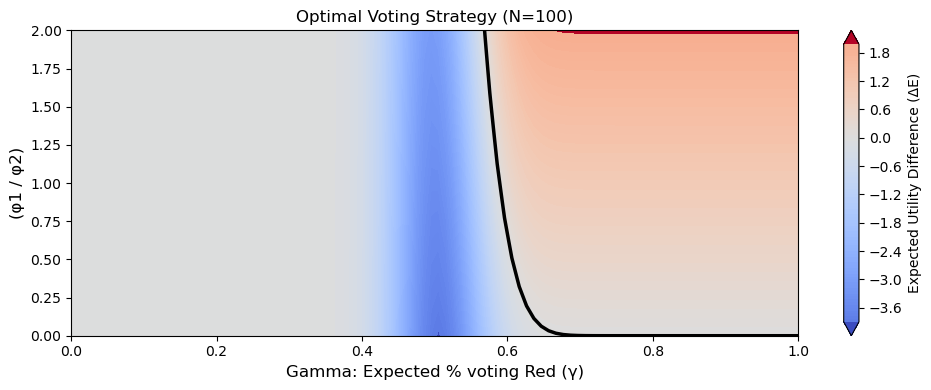

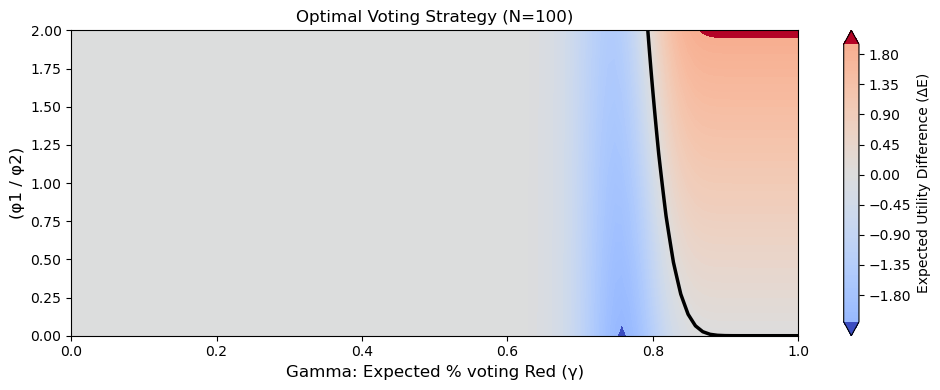

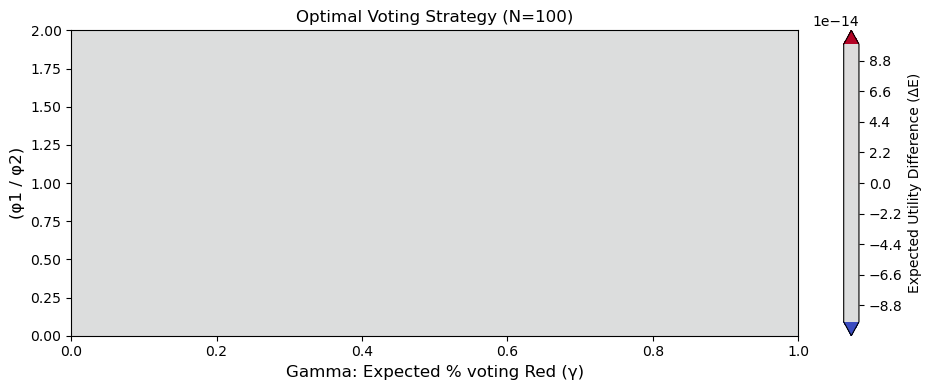

In [7]:
plot_sweep(compute_sweep(N=100, resolution=100, ratio_min=0, ratio_max=2, ratio_scale="linear", threshold=0))
plot_sweep(compute_sweep(N=100, resolution=100, ratio_min=0, ratio_max=2, ratio_scale="linear", threshold=0.25))
plot_sweep(compute_sweep(N=100, resolution=100, ratio_min=0, ratio_max=2, ratio_scale="linear", threshold=0.5))
plot_sweep(compute_sweep(N=100, resolution=100, ratio_min=0, ratio_max=2, ratio_scale="linear", threshold=0.75))
plot_sweep(compute_sweep(N=100, resolution=100, ratio_min=0, ratio_max=2, ratio_scale="linear", threshold=1.0))

Under these new rules, the threshold is changed for the number of required votes for red to win, but the number of people punished in the case that red wins is still the same (all of the blue voters).

A couple of notes:
1. The population size determines how deep the expected utility difference valley will be near the threshold gamma.
2. Since the threshold is related to the maximum expected number of people who would be saved by voting blue, the lower the threshold, the deeper the expected utility difference valley will be near the threshold.

By examining this at a fixed population size and resolution, we can observe some very interesting outcomes:
- threshold = 0: *someone always dies if anybody votes red*
- - 
- threshold = 0.25-0.75: t

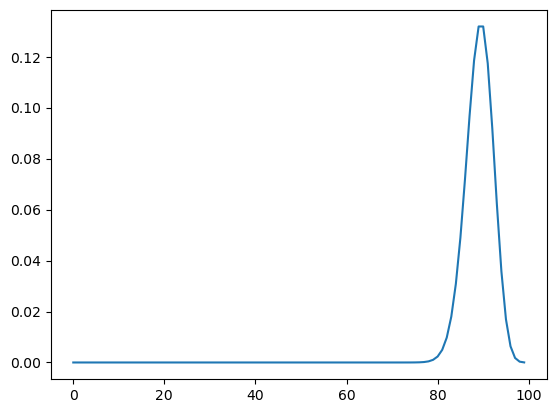

In [8]:
N=100
k = np.arange(N)                                  # shape (N,)
probabilities = binom.pmf(k, N - 1, 0.9)      # shape (..., N)
plt.plot(probabilities)

In [9]:
def convergence_errors_between_resolutions(N, resolutions, ratio_scale="linear", ratio_min=1e-3, ratio_max=50.0):
    """Compare delta_E grids at nested resolutions and report max and RMS errors."""
    sweeps = {}
    for r in resolutions:
        sweeps[r] = compute_sweep(
            N=N,
            resolution=r,
            ratio_min=ratio_min,
            ratio_max=ratio_max,
            ratio_scale=ratio_scale,
        )["delta_e"]

    comparisons = []
    for i in range(len(resolutions) - 1):
        r_coarse = resolutions[i]
        r_fine = resolutions[i + 1]

        step = (r_fine - 1) // (r_coarse - 1)
        if (r_fine - 1) % (r_coarse - 1) != 0:
            raise ValueError("Resolutions must be nested so (r_fine-1) is divisible by (r_coarse-1).")

        fine_on_coarse = sweeps[r_fine][::step, ::step]
        diff = sweeps[r_coarse] - fine_on_coarse

        comparisons.append(
            {
                "scale": ratio_scale,
                "coarse": r_coarse,
                "fine": r_fine,
                "max_abs_err": float(np.max(np.abs(diff))),
                "rmse": float(np.sqrt(np.mean(diff ** 2))),
            }
        )

    return comparisons


def analytical_delta_e(N, phi1, gamma):
    """Closed-form delta_E for this model: pivotal probability times phi1."""
    pivotal_k = int(np.floor(N / 2.0))
    return phi1 * binom.pmf(pivotal_k, N - 1, gamma)


def numerical_vs_analytical_error(N_values, gamma_values, phi1=3.0, phi2=1.0):
    """Check numerical stability by comparing to the closed-form delta_E expression."""
    out = []
    for N in N_values:
        E_red, E_blue = compute_expected_utilities(N, phi1=phi1, phi2=phi2, gamma=gamma_values)
        delta_num = E_red - E_blue
        delta_ref = analytical_delta_e(N=N, phi1=phi1, gamma=gamma_values)

        err = delta_num - delta_ref
        out.append(
            {
                "N": int(N),
                "max_abs_err": float(np.max(np.abs(err))),
                "rmse": float(np.sqrt(np.mean(err ** 2))),
            }
        )
    return out


Resolution convergence (coarse vs fine):
scale=linear   33 -> 65   max|err|=0.000e+00  rmse=0.000e+00
scale=linear   65 -> 129  max|err|=0.000e+00  rmse=0.000e+00
scale=   log   33 -> 65   max|err|=0.000e+00  rmse=0.000e+00
scale=   log   65 -> 129  max|err|=0.000e+00  rmse=0.000e+00

Closed-form agreement check:
N= 25  max|err|=3.000e+00  rmse=1.790e+00
N= 50  max|err|=3.000e+00  rmse=1.900e+00
N=100  max|err|=3.000e+00  rmse=2.051e+00
N=200  max|err|=4.417e+00  rmse=2.223e+00
N=400  max|err|=6.673e+00  rmse=2.516e+00


/var/folders/vh/gddtsmpd0h12dlxhtzb0lqkr0000gn/T/ipykernel_19526/1787681751.py:61: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


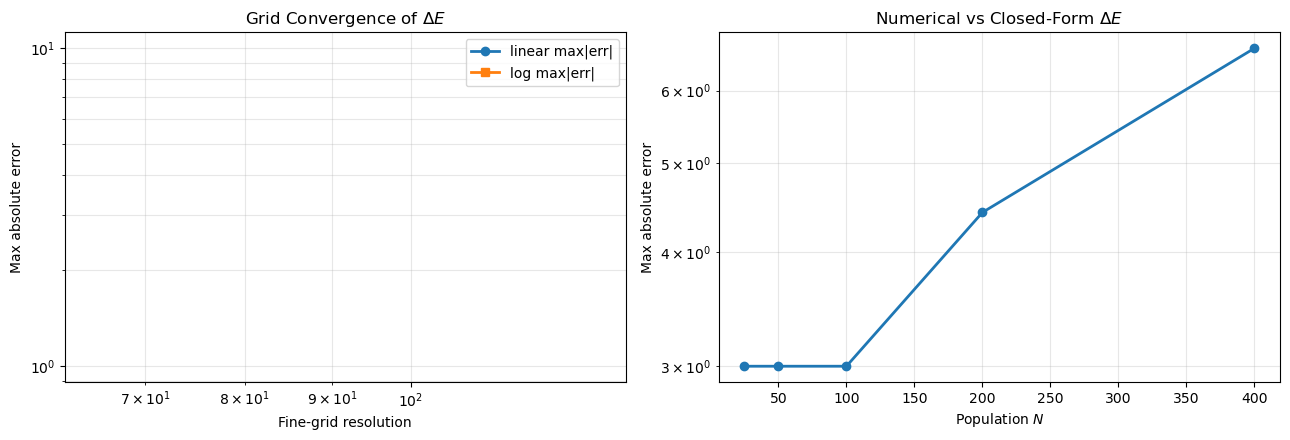

In [10]:
# --- Convergence study 1: sweep-grid resolution ---
N_conv = 80
nested_resolutions = [33, 65, 129]  # nested grids: r_fine = 2 * r_coarse - 1

linear_conv = convergence_errors_between_resolutions(
    N=N_conv,
    resolutions=nested_resolutions,
    ratio_scale="linear",
    ratio_min=0.0,
    ratio_max=50.0,
)

log_conv = convergence_errors_between_resolutions(
    N=N_conv,
    resolutions=nested_resolutions,
    ratio_scale="log",
    ratio_min=1e-3,
    ratio_max=50.0,
)

print("Resolution convergence (coarse vs fine):")
for row in linear_conv + log_conv:
    print(
        f"scale={row['scale']:>6}  {row['coarse']:>3} -> {row['fine']:<3}  "
        f"max|err|={row['max_abs_err']:.3e}  rmse={row['rmse']:.3e}"
    )

# --- Convergence study 2: numerical vs closed-form delta_E ---
N_values = [25, 50, 100, 200, 400]
gamma_values = np.linspace(0.05, 0.95, 19)
closed_form_err = numerical_vs_analytical_error(N_values, gamma_values, phi1=3.0, phi2=1.0)

print("\nClosed-form agreement check:")
for row in closed_form_err:
    print(f"N={row['N']:>3}  max|err|={row['max_abs_err']:.3e}  rmse={row['rmse']:.3e}")

# --- Plot diagnostics ---
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: resolution convergence
for label, rows, marker in [("linear", linear_conv, "o"), ("log", log_conv, "s")]:
    x = [r["fine"] for r in rows]
    y = [r["max_abs_err"] for r in rows]
    axs[0].loglog(x, y, marker=marker, linewidth=2, label=f"{label} max|err|")

axs[0].set_title("Grid Convergence of $\\Delta E$")
axs[0].set_xlabel("Fine-grid resolution")
axs[0].set_ylabel("Max absolute error")
axs[0].grid(True, which="both", alpha=0.3)
axs[0].legend()

# Right: analytical agreement vs N
xN = [r["N"] for r in closed_form_err]
yN = [r["max_abs_err"] for r in closed_form_err]
axs[1].semilogy(xN, yN, marker="o", linewidth=2)
axs[1].set_title("Numerical vs Closed-Form $\\Delta E$")
axs[1].set_xlabel("Population $N$")
axs[1].set_ylabel("Max absolute error")
axs[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()
